In [1]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print(f"✅ SHAP version: {shap.__version__}")

✅ SHAP version: 0.51.0


In [2]:
model_path = "../models/saved/"
data_path  = "../data/processed/"

rf_binary        = joblib.load(model_path + "rf_binary.pkl")
selected_features = joblib.load(model_path + "selected_features.pkl")

X_test = np.load(data_path + "X_test.npy")
y_test = np.load(data_path + "y_test.npy")

# Use a small sample for SHAP (it's computationally heavy)
sample_size = 500
X_sample = X_test[:sample_size]
y_sample = y_test[:sample_size]

X_sample_df = pd.DataFrame(X_sample, columns=selected_features)

print(f"✅ Models loaded")
print(f"✅ Sample size: {X_sample.shape}")

✅ Models loaded
✅ Sample size: (500, 40)


In [3]:
print("Building SHAP TreeExplainer (this takes 1-2 min)...")

explainer    = shap.TreeExplainer(rf_binary)
shap_values  = explainer.shap_values(X_sample_df)

# For binary classification, shap_values is a list [class0, class1]
# We want class 1 (attack)
if isinstance(shap_values, list):
    sv_attack = shap_values[1]
else:
    sv_attack = shap_values

print(f"✅ SHAP values computed")
print(f"   Shape: {sv_attack.shape}")

Building SHAP TreeExplainer (this takes 1-2 min)...
✅ SHAP values computed
   Shape: (500, 40, 2)


<Figure size 1200x800 with 0 Axes>

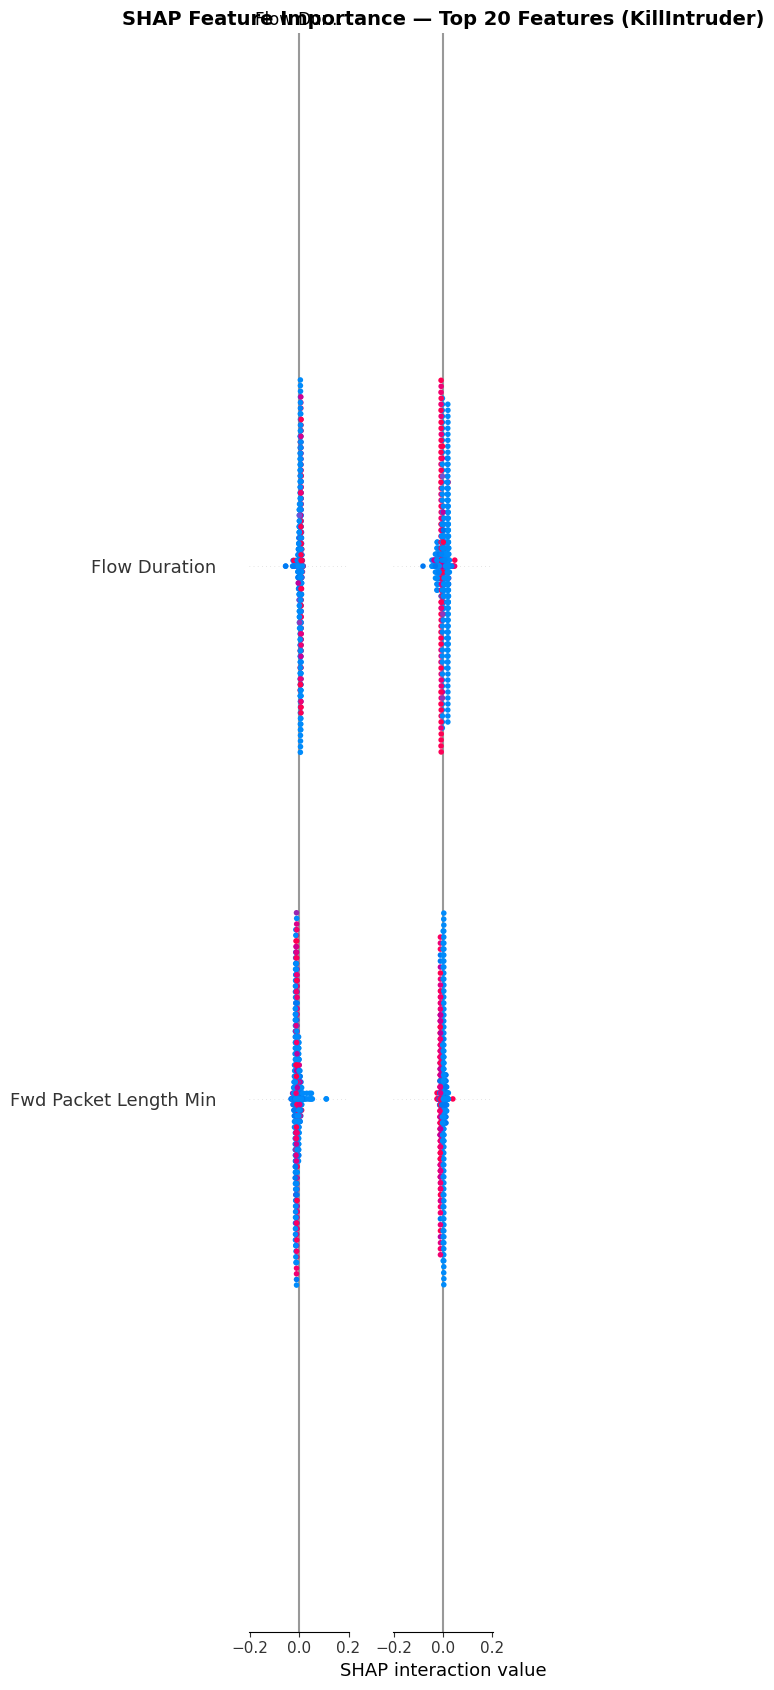

✅ Saved to reports/shap_importance.png


In [4]:
plt.figure(figsize=(12, 8))
shap.summary_plot(
    sv_attack,
    X_sample_df,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Feature Importance — Top 20 Features (KillIntruder)", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../reports/shap_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to reports/shap_importance.png")

<Figure size 1200x900 with 0 Axes>

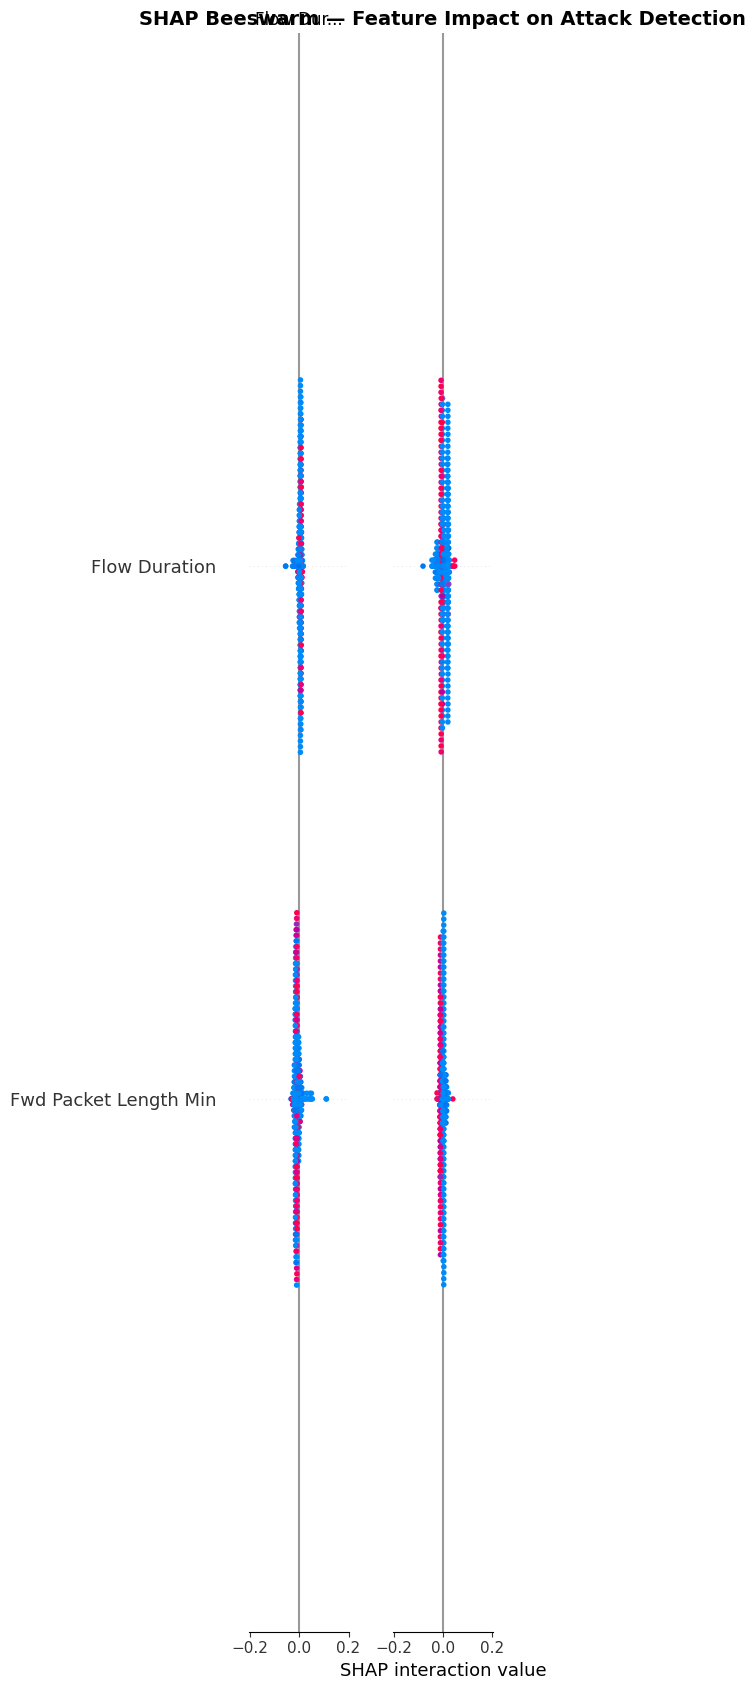

✅ Saved to reports/shap_beeswarm.png


In [5]:
plt.figure(figsize=(12, 9))
shap.summary_plot(
    sv_attack,
    X_sample_df,
    max_display=20,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact on Attack Detection",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../reports/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to reports/shap_beeswarm.png")

Explaining sample #0
True label   : ATTACK
RF prediction: ATTACK
RF confidence: 100.0%


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


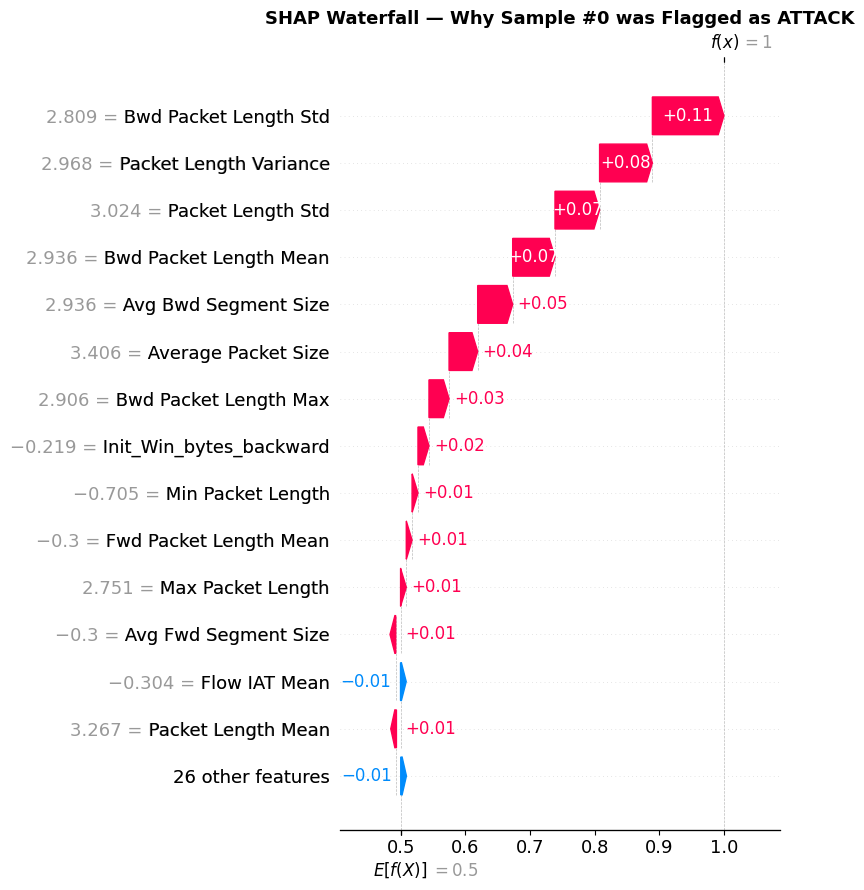

✅ Saved!


In [7]:
# Pick one attack sample to explain
attack_indices = np.where(y_sample == 1)[0]
idx = attack_indices[0]

print(f"Explaining sample #{idx}")
print(f"True label   : {'ATTACK' if y_sample[idx]==1 else 'BENIGN'}")
print(f"RF prediction: {'ATTACK' if rf_binary.predict(X_sample[idx:idx+1])[0]==1 else 'BENIGN'}")
print(f"RF confidence: {rf_binary.predict_proba(X_sample[idx:idx+1])[0][1]*100:.1f}%")

# Fix — handle multi-output SHAP correctly
sv = sv_attack[idx]  # shape (40,) — single sample

# If still 2D, take class 1
if sv.ndim == 2:
    sv = sv[:, 1]

base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[1]

shap_exp = shap.Explanation(
    values        = sv,
    base_values   = float(base_val),
    data          = X_sample_df.iloc[idx].values,
    feature_names = selected_features
)

plt.figure(figsize=(12, 7))
shap.plots.waterfall(shap_exp, max_display=15, show=False)
plt.title(f"SHAP Waterfall — Why Sample #{idx} was Flagged as ATTACK",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../reports/shap_waterfall_attack.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

Explaining sample #2
True label   : BENIGN
RF prediction: BENIGN


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


<Figure size 1200x700 with 0 Axes>

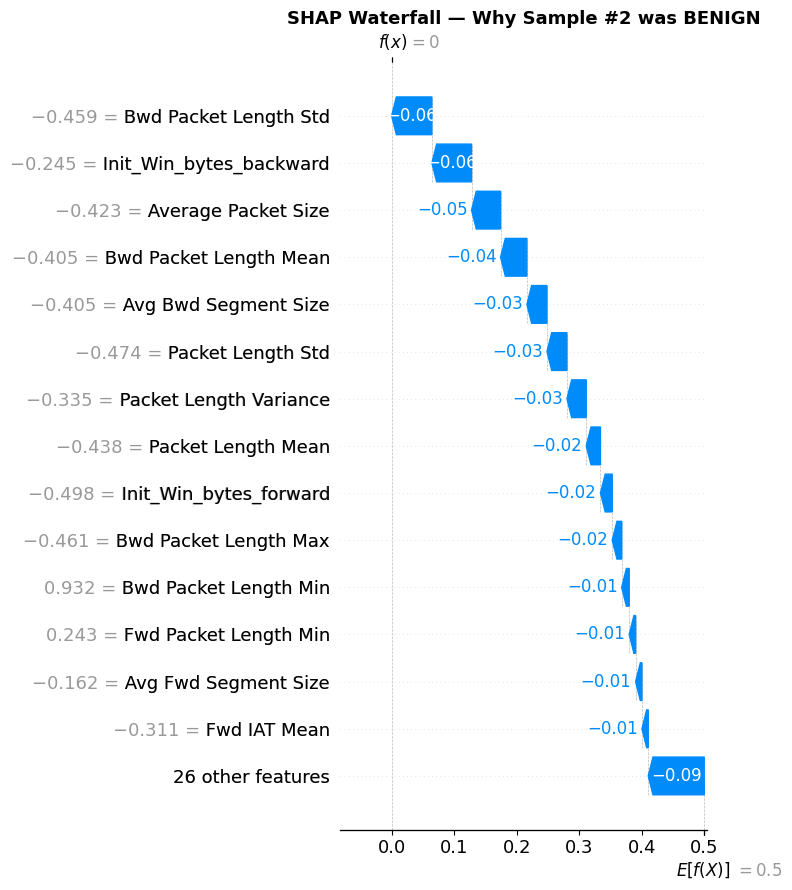

✅ Saved!


In [10]:
benign_indices = np.where(y_sample == 0)[0]
idx_b = benign_indices[0]

print(f"Explaining sample #{idx_b}")
print(f"True label   : BENIGN")
print(f"RF prediction: {'ATTACK' if rf_binary.predict(X_sample[idx_b:idx_b+1])[0]==1 else 'BENIGN'}")

# Fix for multi-output
sv_b = sv_attack[idx_b]
if sv_b.ndim == 2:
    sv_b = sv_b[:, 1]

base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[1]

shap_exp_b = shap.Explanation(
    values        = sv_b,
    base_values   = float(base_val),
    data          = X_sample_df.iloc[idx_b].values,
    feature_names = selected_features
)

plt.figure(figsize=(12, 7))
shap.plots.waterfall(shap_exp_b, max_display=15, show=False)
plt.title(f"SHAP Waterfall — Why Sample #{idx_b} was BENIGN",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../reports/shap_waterfall_benign.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

In [12]:
# Fix for multi-output — take class 1 slice
if sv_attack.ndim == 3:
    sv_for_importance = sv_attack[:, :, 1]  # shape (samples, features)
elif sv_attack.ndim == 2 and sv_attack.shape[1] == 2:
    sv_for_importance = sv_attack[:, 1]
else:
    sv_for_importance = sv_attack

mean_shap = np.abs(sv_for_importance).mean(axis=0)

# Make sure mean_shap is 1D
mean_shap = np.array(mean_shap).flatten()

p75 = float(np.percentile(mean_shap, 75))
p50 = float(np.percentile(mean_shap, 50))

shap_df = pd.DataFrame({
    'Feature'    : selected_features,
    'Mean |SHAP|': mean_shap,
    'Impact'     : ['HIGH' if float(v) > p75
                    else 'MEDIUM' if float(v) > p50
                    else 'LOW' for v in mean_shap]
}).sort_values('Mean |SHAP|', ascending=False)

print("=== Top 15 Most Influential Features for Attack Detection ===\n")
print(shap_df.head(15).to_string(index=False))

shap_df.to_csv("../reports/shap_feature_importance.csv", index=False)
print("\n✅ Saved to reports/shap_feature_importance.csv")

=== Top 15 Most Influential Features for Attack Detection ===

                Feature  Mean |SHAP| Impact
  Bwd Packet Length Std     0.076789   HIGH
Init_Win_bytes_backward     0.050857   HIGH
 Bwd Packet Length Mean     0.042801   HIGH
    Average Packet Size     0.041031   HIGH
 Packet Length Variance     0.037399   HIGH
      Packet Length Std     0.036241   HIGH
   Avg Bwd Segment Size     0.034671   HIGH
 Init_Win_bytes_forward     0.020101   HIGH
  Bwd Packet Length Max     0.018168   HIGH
     Packet Length Mean     0.015503   HIGH
          Bwd Packets/s     0.012194 MEDIUM
            Fwd IAT Max     0.011860 MEDIUM
   Avg Fwd Segment Size     0.011651 MEDIUM
 Fwd Packet Length Mean     0.011559 MEDIUM
            Fwd IAT Std     0.010577 MEDIUM

✅ Saved to reports/shap_feature_importance.csv


In [13]:
joblib.dump(explainer, model_path + "shap_explainer.pkl")
print("✅ SHAP explainer saved to models/saved/shap_explainer.pkl")

print("\n=== SHAP Summary ===")
print(f"Top 5 attack indicators:")
for i, row in shap_df.head(5).iterrows():
    print(f"  {row['Feature']:40s} SHAP={row['Mean |SHAP|']:.4f}  [{row['Impact']}]")

✅ SHAP explainer saved to models/saved/shap_explainer.pkl

=== SHAP Summary ===
Top 5 attack indicators:
  Bwd Packet Length Std                    SHAP=0.0768  [HIGH]
  Init_Win_bytes_backward                  SHAP=0.0509  [HIGH]
  Bwd Packet Length Mean                   SHAP=0.0428  [HIGH]
  Average Packet Size                      SHAP=0.0410  [HIGH]
  Packet Length Variance                   SHAP=0.0374  [HIGH]
